<h1>Variable Continua: Precio (Y)</h1>

## I. Histograma
Agruparemos los resultados en intervalos utilizando la **Regla de Sturges**:

$$
{\text{k} = \left[1 + 3,322\log_{10}{n}\right]}
$$

Cantidad de datos (n): 24485
Intervalos calculados (k): 16


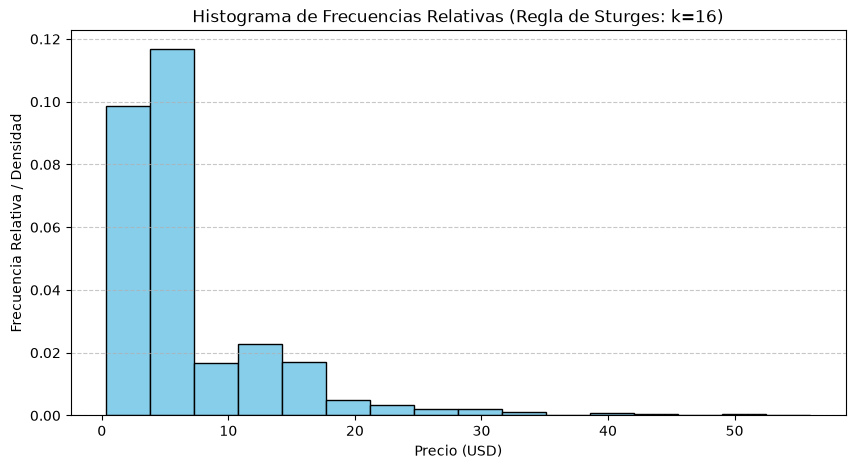

In [1]:
%run scripts/histograma.py

## II. Identificación visual

Podemos observar que las barras tienen un breve crecimiento en el segundo intervalo, pero luego **decrecen rápidamente**. Si bien esto se aleja levemente de una Exponencial pura (que debería decaer monótonamente desde el primer intervalo), la tendencia dominante es de caída rápida, lo cual es consistente con este modelo. Esto se debe a que la mayoría de los juegos en Steam son títulos económicos (indies, juegos pequeños), mientras que muy pocos alcanzan precios elevados (ediciones AAA o de colección). Por lo tanto, conviene elegir el modelo **Exponencial**.

### III. Parametrización

Al identificar en la Fase 2 que el precio de los juegos se comporta como una variable **Exponencial**, necesitamos saber el parámetro $\lambda$ (tasa) que define la curva específica de nuestro modelo:

$$
f_Y(y) = \lambda\, e^{-\lambda y}, \quad y \ge 0
$$

Usamos el método de los momentos: la Exponencial tiene una media teórica igual a $1/\lambda$. Igualando esa media teórica con la media muestral $\bar y$ de nuestros datos y despejando:

$$
\lambda = \frac{1}{\bar y}
$$

El siguiente script calcula $\lambda$ a partir de los datos y reemplaza su valor en el modelo para obtener la curva específica:

In [ ]:
%run scripts/parametrizacion.py

Esta curva la usaremos en la Fase 4 para calcular probabilidades.

## IV. Cálculos guiados

### Verificación de normalización

Para que $f_Y(y)$ sea una función de densidad válida, **el área total bajo la curva debe ser igual a 1**:

$$
\int_0^{\infty} f_Y(y)\,dy = \int_0^{\infty} \lambda e^{-\lambda y}\,dy
$$

**Paso 1 — Regla del múltiplo constante:** como $\lambda$ es una constante (no depende de $y$), se puede sacar fuera de la integral:

$$
\int_0^{\infty} \lambda e^{-\lambda y}\,dy = \lambda \int_0^{\infty} e^{-\lambda y}\,dy
$$

**Paso 2 — Regla de la exponencial:** para integrar una exponencial de la forma $e^{ky}$ (con $k$ constante), se usa la regla general

$$
\int e^{ky}\,dy = \frac{1}{k}e^{ky} + C
$$

En nuestro caso $k=-\lambda$, entonces:

$$
\int e^{-\lambda y}\,dy = \frac{1}{-\lambda}e^{-\lambda y} + C = -\frac{1}{\lambda}e^{-\lambda y} + C
$$

**Paso 3 — Combinar ambos pasos:** multiplicamos ese resultado por el $\lambda$ que habíamos sacado en el Paso 1 (se cancela con el $1/\lambda$):

$$
\lambda \cdot \left(-\frac{1}{\lambda}e^{-\lambda y}\right) = -e^{-\lambda y}
$$

Esa es la antiderivada de $f_Y(y)$. Ahora la evaluamos entre los límites 0 e infinito:

$$
\Big[-e^{-\lambda y}\Big]_0^{\infty} = \lim_{y\to\infty}\left(-e^{-\lambda y}\right) - \left(-e^{-\lambda \cdot 0}\right)
$$

- Cuando $y\to\infty$: como $\lambda>0$, el exponente $-\lambda y \to -\infty$, entonces $e^{-\lambda y}\to 0$. Ese término vale $0$.
- Cuando $y=0$: $e^{-\lambda \cdot 0} = e^0 = 1$, entonces ese término vale $-(-1) = 1$.

$$
\Big[-e^{-\lambda y}\Big]_0^{\infty} = 0 - (-1) = 1
$$

Por lo tanto, la función de densidad está **correctamente normalizada**.

### Función de Distribución Acumulada

Por definición, la función de distribución acumulada es la probabilidad de que $Y$ tome un valor menor o igual a $y$, es decir, el área bajo $f_Y$ desde 0 hasta $y$:

$$
F_Y(y) = P(Y \le y) = \int_0^{y} f_Y(t)\,dt = \int_0^{y} \lambda e^{-\lambda t}\,dt
$$

**Paso 1 — Antiderivada:** usando la misma regla de la exponencial que aplicamos en la verificación de normalización, la antiderivada de $\lambda e^{-\lambda t}$ es $-e^{-\lambda t}$:

$$
\int_0^{y} \lambda e^{-\lambda t}\,dt = \Big[-e^{-\lambda t}\Big]_0^{y}
$$

**Paso 2 — Evaluar en los límites** (esta vez entre $0$ y $y$, no entre $0$ e infinito):

$$
\Big[-e^{-\lambda t}\Big]_0^{y} = \left(-e^{-\lambda y}\right) - \left(-e^{-\lambda \cdot 0}\right)
$$

- En $t=y$: queda $-e^{-\lambda y}$.
- En $t=0$: $e^{-\lambda \cdot 0} = e^0 = 1$, entonces ese término vale $-(-1) = 1$.

**Paso 3 — Resultado:**

$$
F_Y(y) = -e^{-\lambda y} + 1 = 1 - e^{-\lambda y}, \quad y \ge 0
$$

### Desviación estándar muestral ($s$)

Mide que tan esparcidos estan los datos con respecto al promedio (la media muestral). Se representa con la letra *s* y se calcula como:

$$
s = \sqrt{\dfrac{1}{n-1}\sum_{i=1}^{n}(y_i - \bar y)^2}
$$

La usamos junto con $\bar y$ para calcular $P(Y > \bar y + s)$: la probabilidad de que un juego tenga un precio inusualmente alto.
### Probabilidades concretas

Usando $F_Y(y)$ calculamos:

$$
P(Y \le \bar y) = F_Y(\bar y) \qquad\qquad P(Y > \bar y + s) = 1 - F_Y(\bar y + s)
$$

In [ ]:
%run scripts/calculos.py

En base a esto, concluimos que hay una probabilidad del 63,21% que un juego tenga un precio inferior al promedio y del 13% que un juego tenga un precio mucho mas alto que el promedio (generalmente uno AAA).